In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict , Literal , Annotated
from langchain_ollama import ChatOllama
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
from langgraph.checkpoint.memory import InMemorySaver
  

In [2]:
class JokeState(TypedDict):
    topic: str
    joke : str
    explanation : str

In [4]:
llm = ChatOllama(model="Phi3")

In [5]:
def generator_joke (state : JokeState) -> JokeState:
    
    prompt = f'generate a joke about {state["topic"]}' 
    response = llm.invoke(prompt).content

    return {'joke' : response }

In [6]:
def generator_explanation ( state : JokeState):
    
    prompt = f'write an explanation for the joke - {state["joke"]}' 
    response = llm.invoke(prompt).content

    return {'explanation' : response }

In [7]:
graph = StateGraph(JokeState)

graph.add_node('generator_joke', generator_joke)
graph.add_node('generator_explanation', generator_explanation)


graph.add_edge(START, 'generator_joke')
graph.add_edge('generator_joke', 'generator_explanation')
graph.add_edge('generator_explanation', END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer = checkpointer)


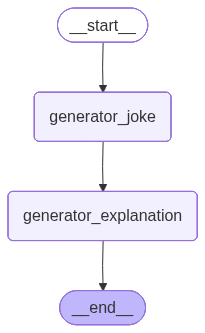

In [8]:
workflow

In [9]:
config1 = {"configurable" : {"thread_id" : "1"}}
workflow.invoke({"topic" : "chickens"}, config = config1)

{'topic': 'chickens',
 'joke': 'Why don\'t chickens use forums to communicate? Because they always end up in "clucks" of argument and can never agree on what’s “egg-straordinary”! And that one time, he said it was too close for comfort because the rooster wanted his personal space. I guess we all have our pecking order when online discussions get frothy!',
 'explanation': 'Here\'s an explanation of this humorous take on why chickens might not use internet discussion platforms like forums: The joke plays off two main aspects – the natural behaviors and social structures within a flock, as well as typical situations that can cause conflict or misunderstanding in human online interactions.\n\nIn real life, chickens have established ways of communicating with each other through various sounds and movements; they don\'t use forums to chat because it doesn’t align with their methods of interaction. The joke humorously suggests a situation where the communication style humans adopt on these p

In [10]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'chickens', 'joke': 'Why don\'t chickens use forums to communicate? Because they always end up in "clucks" of argument and can never agree on what’s “egg-straordinary”! And that one time, he said it was too close for comfort because the rooster wanted his personal space. I guess we all have our pecking order when online discussions get frothy!', 'explanation': 'Here\'s an explanation of this humorous take on why chickens might not use internet discussion platforms like forums: The joke plays off two main aspects – the natural behaviors and social structures within a flock, as well as typical situations that can cause conflict or misunderstanding in human online interactions.\n\nIn real life, chickens have established ways of communicating with each other through various sounds and movements; they don\'t use forums to chat because it doesn’t align with their methods of interaction. The joke humorously suggests a situation where the communication style huma

In [11]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'chickens', 'joke': 'Why don\'t chickens use forums to communicate? Because they always end up in "clucks" of argument and can never agree on what’s “egg-straordinary”! And that one time, he said it was too close for comfort because the rooster wanted his personal space. I guess we all have our pecking order when online discussions get frothy!', 'explanation': 'Here\'s an explanation of this humorous take on why chickens might not use internet discussion platforms like forums: The joke plays off two main aspects – the natural behaviors and social structures within a flock, as well as typical situations that can cause conflict or misunderstanding in human online interactions.\n\nIn real life, chickens have established ways of communicating with each other through various sounds and movements; they don\'t use forums to chat because it doesn’t align with their methods of interaction. The joke humorously suggests a situation where the communication style hum

In [14]:
config1 = {"configurable" : {"thread_id" : "2"}}
workflow.invoke({"topic" : "Engineering "}, config = config1)

{'topic': 'Engineering ',
 'joke': '\nWhy was the engineering team always successful? Because they had great "foundations" of knowledge! 😄 And don\'t worry, all their project plans are drawn up with clear and accurate details – no one likes surprises on construction sites or in life. Just like a well-engineered beam supports loads without failure...or at least we hope so before the annual safety inspections begin!',
 'explanation': 'The joke plays off of typical stereotypes associated with engineering and scientific fields, where precision, accuracy, and meticulous planning are often highlighted as key to success. In this humorous take, it implies that an "engineering team" always succeeds due to their strong foundational knowledge in these areas – just like the way a well-planned beam or foundation is critical for any structure\'th safety and stability.\n\nIn essence, while all engineers value solid groundwork (knowledge), this joke pokes fun at the idea that it\'s only because they "

In [17]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'Engineering ', 'joke': '\nWhy was the engineering team always successful? Because they had great "foundations" of knowledge! 😄 And don\'t worry, all their project plans are drawn up with clear and accurate details – no one likes surprises on construction sites or in life. Just like a well-engineered beam supports loads without failure...or at least we hope so before the annual safety inspections begin!', 'explanation': 'The joke plays off of typical stereotypes associated with engineering and scientific fields, where precision, accuracy, and meticulous planning are often highlighted as key to success. In this humorous take, it implies that an "engineering team" always succeeds due to their strong foundational knowledge in these areas – just like the way a well-planned beam or foundation is critical for any structure\'th safety and stability.\n\nIn essence, while all engineers value solid groundwork (knowledge), this joke pokes fun at the idea that it\'s 

In [19]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'Engineering ', 'joke': '\nWhy was the engineering team always successful? Because they had great "foundations" of knowledge! 😄 And don\'t worry, all their project plans are drawn up with clear and accurate details – no one likes surprises on construction sites or in life. Just like a well-engineered beam supports loads without failure...or at least we hope so before the annual safety inspections begin!', 'explanation': 'The joke plays off of typical stereotypes associated with engineering and scientific fields, where precision, accuracy, and meticulous planning are often highlighted as key to success. In this humorous take, it implies that an "engineering team" always succeeds due to their strong foundational knowledge in these areas – just like the way a well-planned beam or foundation is critical for any structure\'th safety and stability.\n\nIn essence, while all engineers value solid groundwork (knowledge), this joke pokes fun at the idea that it\'s